In [8]:
import pandas as pd

In [9]:
# first I have mounted my google drive
sales = pd.read_csv('/content/drive/MyDrive/Data Science practice/Datasets/store_sales_forcasting/sales.csv')
features = pd.read_csv('/content/drive/MyDrive/Data Science practice/Datasets/store_sales_forcasting/features.csv')
stores = pd.read_csv('/content/drive/MyDrive/Data Science practice/Datasets/store_sales_forcasting/stores.csv')
# here I have created 3 dataframe using read_csv method/function.

In [33]:
# basic inspection of df
sales.info()
print(sales.columns.dtype)
print(list(sales.columns))
print(list(features.columns))
print(list(stores.columns))
sales.nunique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156000 entries, 0 to 155999
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   store_id      156000 non-null  int64  
 1   department    156000 non-null  int64  
 2   date          156000 non-null  object 
 3   weekly_sales  156000 non-null  float64
 4   is_holiday    156000 non-null  int64  
dtypes: float64(1), int64(3), object(1)
memory usage: 6.0+ MB
object
['store_id', 'department', 'date', 'weekly_sales', 'is_holiday']
['store_id', 'date', 'temperature', 'fuel_price', 'markdown_1', 'markdown_2', 'markdown_3', 'markdown_4', 'markdown_5', 'cpi', 'unemployment', 'is_holiday', 'holiday_name', 'season']
['store_id', 'store_type', 'store_size', 'region']


,0
store_id,50
department,20
date,156
weekly_sales,154981
is_holiday,2


In [34]:
# @title
# Merge in pandas : It is similar to JOIN of SQL.
# Syntax:
# result = pd.merge(left_df, right_df, on='column_name')
# pd.merge(df1, df2, on='id', how='outer')  --> how parmenters inputs - 'inner', 'left', 'right', 'outer'

# Merge on different column names
# pd.merge(df1, df2, left_on='id1', right_on='id2')

# Merge on index??
# pd.merge(df1, df2, left_index=True, right_index=True)

# Handling duplicate column names
#pd.merge(df1, df2, on='id', suffixes=('_left', '_right'))

In [40]:
merged_df = pd.merge(sales,stores, on='store_id', how = 'left' )
merged_df

,store_id,department,date,weekly_sales,is_holiday,store_type,store_size,region
0,1,1,2022-01-01,119075.96,1,A,213810,North
1,1,2,2022-01-01,119107.85,1,A,213810,North
2,1,3,2022-01-01,84369.88,1,A,213810,North
3,1,4,2022-01-01,88445.24,1,A,213810,North
4,1,5,2022-01-01,65159.85,1,A,213810,North
...,...,...,...,...,...,...,...,...
155995,50,16,2024-12-21,185637.84,1,A,148726,East
155996,50,17,2024-12-21,144644.08,1,A,148726,East
155997,50,18,2024-12-21,102313.34,1,A,148726,East
155998,50,19,2024-12-21,233651.09,1,A,148726,East


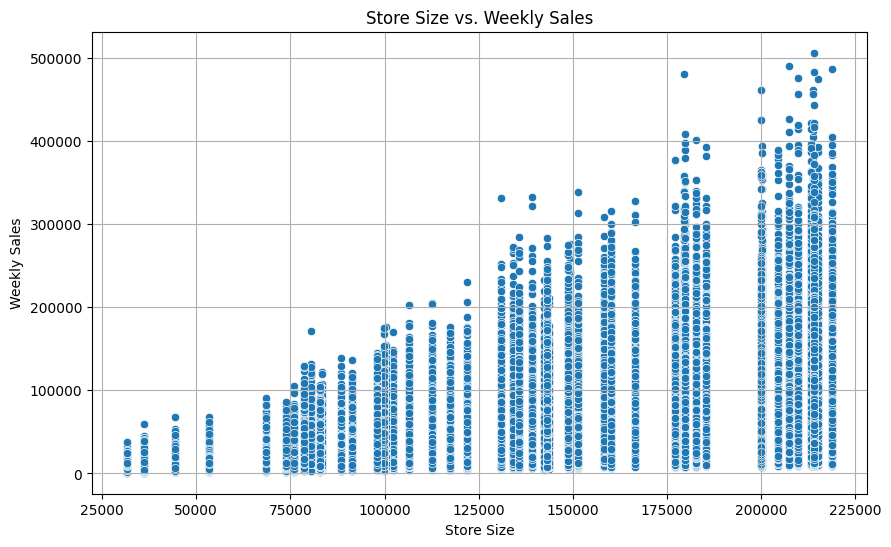

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a scatter plot to visualize the relationship between store_size and weekly_sales
plt.figure(figsize=(10, 6))
sns.scatterplot(x='store_size', y='weekly_sales', data=merged_df)
plt.title('Store Size vs. Weekly Sales')
plt.xlabel('Store Size')
plt.ylabel('Weekly Sales')
plt.grid(True)
plt.show()

In [39]:
# Calculate the correlation between store_size and weekly_sales
correlation = merged_df['store_size'].corr(merged_df['weekly_sales'])
print(f"Correlation between Store Size and Weekly Sales: {correlation}")

Correlation between Store Size and Weekly Sales: 0.5858984837015677
